In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np

import sys
from pathlib import Path

# notebook is in notebooks/, so go up one level to repo root, then into src
sys.path.insert(0, str(Path("..").resolve()))

from src.meteo.province import ProvinceMeteo

In [159]:
start_date = pd.Timestamp("2025-01-01", tz = 'UTC')
end_date = pd.Timestamp("2026-03-01", tz = 'UTC')
reference_station = '09700MS'

province_handler = ProvinceMeteo(timezone = 'Europe/Rome')

lat = 46.623755
lon = 10.78027
models = ['meteoswiss_icon_seamless', 'best_match', "meteofrance_seamless","knmi_seamless","italia_meteo_arpae_icon_2i","icon_seamless"]
day_offset = 2
previous_runs_url_template = "https://previous-runs-api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=shortwave_radiation_previous_day{day_offset}&models={models}&start_date={start_date:%Y-%m-%d}&end_date={end_date:%Y-%m-%d}"

Load data from the reference province station

In [160]:
async def get_observed_data():
    async with province_handler as prv:
        observed_data = await prv.run(
            start = start_date,
            end = end_date,
            station_id = reference_station
        )
    
    observed_data = observed_data[['datetime', 'model', 'station_id', 'solar_radiation']].copy()

    observed_data = (
        observed_data
        .set_index('datetime')
        .groupby(['model', 'station_id'])
        .resample('h', label='right', closed='right') #because open-meteo uses average of previous hours so timestamps align
        .mean()
        .reset_index()
    )
    
    # keep alignment with forecast range after shifting
    observed_data = observed_data[(observed_data['datetime'] >= start_date) & (observed_data['datetime'] <= end_date)]
    
    return observed_data[['datetime', 'model', 'station_id', 'solar_radiation']]

observed_data = await get_observed_data()

In [161]:
observed_data.head()

sensor,datetime,model,station_id,solar_radiation
0,2025-01-01 00:00:00+00:00,observation,09700MS,0.0
1,2025-01-01 01:00:00+00:00,observation,09700MS,0.0
2,2025-01-01 02:00:00+00:00,observation,09700MS,0.0
3,2025-01-01 03:00:00+00:00,observation,09700MS,0.0
4,2025-01-01 04:00:00+00:00,observation,09700MS,0.0


Load forecast data

In [162]:
def get_forecast_data():

    forecast_data = []
    for model in models:
        request_url = previous_runs_url_template.format(
            lat = lat, lon = lon, models = model, day_offset = day_offset, start_date = start_date, end_date = end_date
        )
        response = requests.get(request_url)
        response.raise_for_status()

        _forecast_data = pd.DataFrame(response.json()['hourly'])
        _forecast_data['time'] = pd.to_datetime(_forecast_data['time'], utc = True)
        _forecast_data.rename(columns = {'time': 'datetime', f'shortwave_radiation_previous_day{day_offset}': 'solar_radiation'}, inplace = True)
        _forecast_data['model'] = model

        forecast_data.append(_forecast_data[['datetime', 'model', 'solar_radiation']])

    return pd.concat(forecast_data, ignore_index = True)

forecast_data = get_forecast_data()

In [163]:
radiation_tbl = pd.concat([observed_data, forecast_data])
radiation_tbl = radiation_tbl.pivot(columns = 'model', values = 'solar_radiation', index = 'datetime')

radiation_tbl['month'] = radiation_tbl.index.month
radiation_tbl['hour'] = radiation_tbl.index.hour

In [164]:
# Build long-format comparison table
observed_series = observed_data[['datetime', 'solar_radiation']].rename(columns={'solar_radiation': 'obs'})
forecast_series = forecast_data[['datetime', 'model', 'solar_radiation']].rename(columns={'solar_radiation': 'fcst'})

comparison_tbl = forecast_series.merge(observed_series, on='datetime', how='inner')
comparison_tbl = comparison_tbl.dropna(subset=['obs', 'fcst'])

# Error components
comparison_tbl['error'] = comparison_tbl['fcst'] - comparison_tbl['obs']
comparison_tbl['abs_error'] = comparison_tbl['error'].abs()
comparison_tbl['sq_error'] = comparison_tbl['error'] ** 2
comparison_tbl['month'] = comparison_tbl['datetime'].dt.month
comparison_tbl['year'] = comparison_tbl['datetime'].dt.year

# Meteorological seasons (DJF, MAM, JJA, SON)
def month_to_season(m):
    if m in (12, 1, 2):
        return 'DJF'
    if m in (3, 4, 5):
        return 'MAM'
    if m in (6, 7, 8):
        return 'JJA'
    return 'SON'

comparison_tbl['season'] = comparison_tbl['month'].apply(month_to_season)

In [165]:
def summarize_metrics(df, group_cols):
    summary = df.groupby(group_cols).agg(
        n=('error', 'size'),
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        bias=('error', 'mean')
    ).reset_index()
    return summary

overall_metrics = summarize_metrics(comparison_tbl, ['model'])
monthly_metrics = summarize_metrics(comparison_tbl, ['model', 'month'])
seasonal_metrics = summarize_metrics(comparison_tbl, ['model', 'season'])

display(overall_metrics.sort_values('rmse'))

# Daily total metrics (better proxy for PV energy)
daily_tbl = comparison_tbl.copy()
daily_tbl['date'] = daily_tbl['datetime'].dt.floor('D')

daily_totals = daily_tbl.groupby(['model', 'date', 'season']).agg(
    obs=('obs', 'sum'),
    fcst=('fcst', 'sum')
).reset_index()
daily_totals['error'] = daily_totals['fcst'] - daily_totals['obs']
daily_totals['abs_error'] = daily_totals['error'].abs()
daily_totals['sq_error'] = daily_totals['error'] ** 2

daily_overall_metrics = summarize_metrics(daily_totals, ['model'])
daily_seasonal_metrics = summarize_metrics(daily_totals, ['model', 'season'])

display(daily_overall_metrics.sort_values('rmse'))

,model,n,mae,rmse,bias
5,meteoswiss_icon_seamless,5737,34.910060,80.490548,14.176193
0,best_match,10177,37.621224,82.514555,5.269939
1,icon_seamless,10177,37.621224,82.514555,5.269939
3,knmi_seamless,10177,40.342154,86.746081,16.655416
2,italia_meteo_arpae_icon_2i,7510,46.645550,92.387297,-7.459518
4,meteofrance_seamless,10177,41.246055,103.173122,23.478674


,model,n,mae,rmse,bias
5,meteoswiss_icon_seamless,240,512.016458,703.742316,338.870069
0,best_match,425,562.720392,780.802024,126.193333
1,icon_seamless,425,562.720392,780.802024,126.193333
2,italia_meteo_arpae_icon_2i,319,701.118757,913.261169,-175.614368
3,knmi_seamless,425,682.507608,930.014196,398.828627
4,meteofrance_seamless,425,715.628784,1036.469926,562.217569


<Axes: xlabel='hour'>

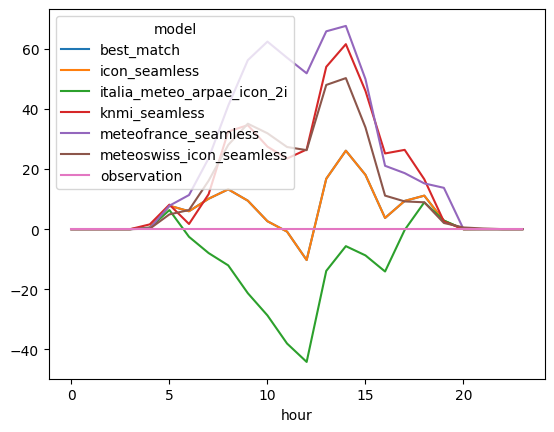

In [142]:
display(seasonal_metrics.sort_values(['season', 'rmse']))
display(daily_seasonal_metrics.sort_values(['season', 'rmse']))

# Heatmap: Monthly MAE by model
pivot_mae = monthly_metrics.pivot(index='model', columns='month', values='mae')

fig, ax = plt.subplots(figsize=(10, 0.5 * len(pivot_mae.index) + 2))
im = ax.imshow(pivot_mae.values, aspect='auto')
ax.set_yticks(range(len(pivot_mae.index)))
ax.set_yticklabels(pivot_mae.index)
ax.set_xticks(range(len(pivot_mae.columns)))
ax.set_xticklabels(pivot_mae.columns)
ax.set_title('Monthly MAE by Model')
fig.colorbar(im, ax=ax, label='MAE (W/m²)')

# Seasonal RMSE bar plot
season_order = ['DJF', 'MAM', 'JJA', 'SON']
seasonal_metrics['season'] = pd.Categorical(seasonal_metrics['season'], categories=season_order, ordered=True)
seasonal_pivot = seasonal_metrics.pivot(index='model', columns='season', values='rmse')

ax = seasonal_pivot.loc[seasonal_pivot.mean(axis=1).sort_values().index].plot(
    kind='bar', figsize=(12, 5), rot=30
)
ax.set_title('Seasonal RMSE by Model')
ax.set_ylabel('RMSE (W/m²)')
ax.legend(title='Season')
plt.tight_layout()

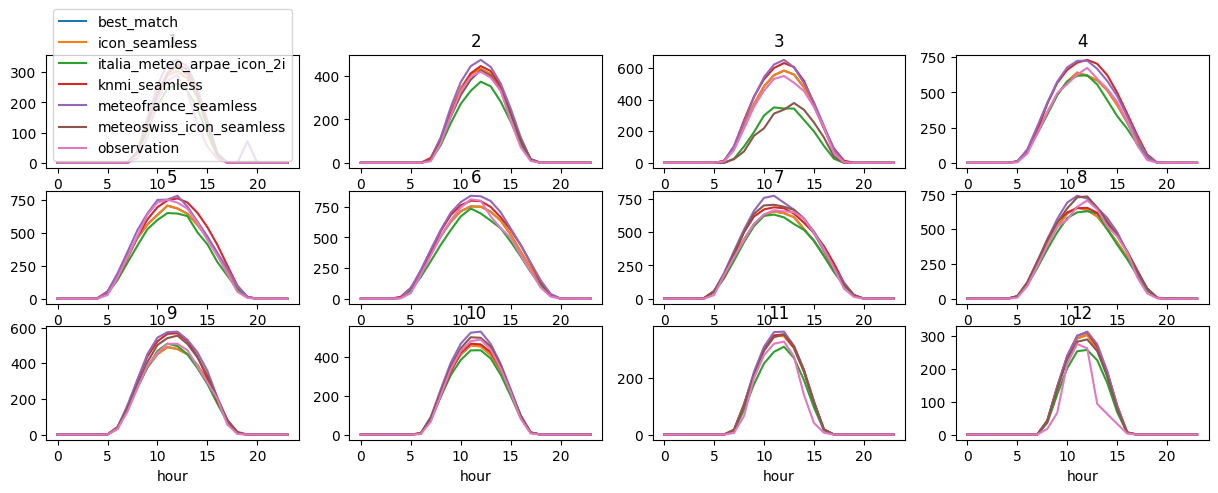

In [143]:
# Optional: diurnal bias profile (aggregate) to inspect systematic timing issues
hourly_bias = comparison_tbl.groupby(['model', comparison_tbl['datetime'].dt.hour]).agg(
    bias=('error', 'mean')
).reset_index().rename(columns={'datetime': 'hour'})

fig, ax = plt.subplots(figsize=(12, 5))
for model, data in hourly_bias.groupby('model'):
    ax.plot(data['hour'], data['bias'], label=model)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_title('Diurnal Bias by Model (Mean Error)')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Bias (W/m²)')
ax.legend(ncol=2)
plt.tight_layout()